# Info

repo: https://github.com/tessgi/secret/tree/christina-sketch1/src/lightkurve

In [1]:
from lightkurve import DataCube, ErrorCube, DataFrame  # , DataSeries
from astropy.io import fits
import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

## Full HDU list

In [2]:
# Run for access to the full fits file, not necessary to run notebook as written
hdulist = fits.open(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)
hdulist.close()

# Prepare DataCube

#### TODO: Consider maximum pandas size, how do we handle FFIs?

In [3]:
with fits.open(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
) as hdulist:
    flux_array = hdulist[1].data["FLUX"].astype(float)
    flux_err_array = hdulist[1].data["FLUX_ERR"].astype(float)
    time = hdulist[1].data["TIME"].astype(float)
    time_corr = hdulist[1].data["TIMECORR"].astype(float)
    c0, r0 = hdulist[1].header["1CRV4P"], hdulist[1].header["2CRV4P"]
    row, col = np.arange(flux_array.shape[1]) + r0, np.arange(flux_array.shape[2]) + c0
    aper = flux_array.mean(axis=0) > 10000
    bkg_aper = flux_array.mean(axis=0) < 4000

    time_mask = hdulist[1].data["QUALITY"] == 0
    exposure = hdulist[1].header["EXPOSURE"]

#### TODO: general
* In progress: Combined Cube object (flux and error) 
  * rename FluxCube
  * make it access everything in the TPF
  * add slicing
* A datacube can be created from incongruous data, but if a datacube is initially created from congruos data and then had an aperture applied, it would be converted to a dataframe. Should it be disallowed to make a datacube with incongruous data or should a masked datacube remain a datacube or a sub-class MaskedCube? the latter makes most sense to me

#### TODO: more than one row or col index breaks things
I.e. WCS coordinates

In [4]:
flux = DataCube(
    flux_array,
    time_indices={
        "btjd": time,
        "spacecraft_time": time - time_corr,
        "exposure_time": np.array([exposure] * 50),
    },
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
    exposure_time=exposure,
)

flux_err = ErrorCube(
    flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
)

In [5]:
flux_err.sum(axis=1)

📈 ErrorSeries (50,)
time_index  btjd         spacecraft_time
0           1325.324261  1325.323506        30.257752
1           1325.345094  1325.344340        30.258377
2           1325.365927  1325.365173        30.261992
3           1325.386761  1325.386006        30.263874
4           1325.407594  1325.406840        30.265872
5           1325.428427  1325.427673        30.271488
6           1325.449260  1325.448506        30.274676
7           1325.470093  1325.469340        30.275830
8           1325.490926  1325.490173        30.278608
9           1325.511759  1325.511006        30.284310
10          1325.532593  1325.531840        30.287702
11          1325.553426  1325.552673        30.290320
12          1325.574259  1325.573506        30.297720
13          1325.595092  1325.594340        30.302044
14          1325.615925  1325.615173        30.301090
15          1325.636758  1325.636006        30.307196
16          1325.657591  1325.656839        30.310774
17          1325.6784

In [63]:
flux.describe_cube(edgeitems=1)

📘 DataCube (50, 6, 6) (ntime, nrow, ncol)

Time indices available: ['time_index', 'btjd', 'spacecraft_time', 'exposure_time']
	time_index      :	[ 0 ... 49]
	btjd            :	[1325.32426118 ... 1326.34508553]
	spacecraft_time :	[1325.32350628 ... 1326.34433921]
	exposure_time   :	0.016499993395

Number of unique 'series': 36

Row names: ['pixel_row']
	pixel_row       :	[257 ... 262]

Column names: ['pixel_column']
	pixel_column    :	[1628 ... 1633]

User defined attributes accessible via `object.key`
(displaying only unique values)
	exposure_time   :	0.016499993395


In [64]:
flux

📘 DataCube (50, 6, 6)

In [25]:
flux.fold(0.3, level="btjd").sort_index(level="phase").droplevel("btjd")[35]

📘 DataCube (1, 6, 6)

In [46]:
flux.downsample?

Signature: flux.downsample(nframes: int = 5, level: int | str = -1)
Docstring: <no docstring>
File:      ~/Repositories/secret/src/lightkurve/mixins.py
Type:      method

In [51]:
flux.fold?

Signature:
flux.fold(
    period: float,
    t0: float = None,
    level: int | str = 1,
    inplace: bool = False,
    label: str = 'phase',
)
Docstring:
Fold data on a given period and adds the folded time as an index.

Parameters
----------
period : float
    The period on which to fold the data. The user must ensure that it
    this has the same units and scale as the level.
t0 : float, optional
    The time at which to start the first period, by default None and t0
    becomes the minimum value of the time array.
level : int|str, optional
    The index level on which to fold, by default 1, presumed to be the
    first time index that aren't cadences.
inplace : bool, optional
    Whether to modify the object itself or return a new object, by default False
label : str, optional
    What label to give the new time index, by default "phase"

Returns
-------
Cube|Frame|Series
    Returns an object of the same type given.
File:      ~/Repositories/secret/src/lightkurve/mixins.py
Type:  

In [56]:
DataFrame(flux[:, [0, 1, 2, 3, 4, 5], :].fold(0.3)).fold(0.2)

,,,series,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
,,,pixel_row,257,257,257,257,257,257,258,258,258,258,...,261,261,261,261,262,262,262,262,262,262
,,,pixel_column,1628,1629,1630,1631,1632,1633,1628,1629,1630,1631,...,1630,1631,1632,1633,1628,1629,1630,1631,1632,1633
time_index,btjd,spacecraft_time,phase,,,,,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,0.000000,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133,2091.041260,2403.761475,42657.632812,65179.886719,...,103074.070312,105171.984375,40686.078125,4181.030273,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008
1,1325.345094,1325.344340,0.104166,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365,2088.742188,2404.846924,42648.261719,65202.703125,...,103073.914062,105171.820312,40717.785156,4182.341797,3494.455322,11068.058594,102138.429688,104423.468750,10720.024414,3498.899414
2,1325.365927,1325.365173,0.208331,975.665710,967.891174,942.014038,1165.668457,1619.722168,2290.568604,2094.772949,2410.153076,42482.433594,65449.781250,...,103073.796875,105179.046875,40789.992188,4188.048340,3490.266602,11046.513672,102138.304688,104430.640625,10729.130859,3501.454590
3,1325.386761,1325.386006,0.312497,979.376587,972.970520,945.712402,1159.484375,1623.469971,2293.927002,2095.965820,2413.635254,42606.925781,65420.988281,...,103066.804688,105164.296875,40812.726562,4189.608398,3493.087891,11046.653320,102131.343750,104423.312500,10736.232422,3501.558594
4,1325.407594,1325.406840,0.416663,979.624390,973.837219,947.865112,1161.242310,1623.600952,2294.077637,2098.286865,2413.797607,42386.238281,65640.031250,...,103059.632812,105164.523438,40953.453125,4197.038574,3494.666016,11042.083008,102124.218750,104416.218750,10752.752930,3509.732422
5,1325.428427,1325.427673,0.520828,983.042419,978.066895,949.849365,1165.843384,1626.385376,2299.407715,2102.291260,2419.361328,42606.902344,65784.171875,...,103059.531250,105164.500000,40889.960938,4196.946289,3491.857422,11023.171875,102124.132812,104416.195312,10745.757812,3508.302002
6,1325.449260,1325.448506,0.624994,985.820435,980.250061,951.908569,1169.730103,1630.028198,2302.799072,2102.219727,2421.653809,42708.250000,65836.125000,...,103066.757812,105171.882812,40880.855469,4195.622070,3494.453125,11016.144531,102131.304688,104423.539062,10738.701172,3512.454102


In [16]:
flux[0, :1, :1]

,pixel_column
,1628
pixel_row,
257,973


In [93]:
# phased.sort_index(level="phase")

📘 DataCube (50, 6, 6)

In [26]:
flux[:, [0]]

UnboundLocalError: cannot access local variable 'row' where it is not associated with a value

In [27]:
flux[:, 0, 0].downsample(5)

📉 DataSeries (8,)
time_index  btjd         spacecraft_time
8.0         1325.490926  1325.490173        4954.178406
13.0        1325.595092  1325.594340        5029.904480
18.0        1325.699258  1325.698506        5058.767334
23.0        1325.803423  1325.802673        5103.663696
28.0        1325.907589  1325.906839        5107.686707
33.0        1326.011755  1326.011006        5108.506653
38.0        1326.115921  1326.115173        5124.103333
43.0        1326.220087  1326.219339        5124.895264
dtype: float64

In [67]:
from lightkurve.dataset import DataSet

In [68]:
db = DataSet()

In [69]:
db


Data Products:
{},
Error Products:
{},
Properties:
[]

In [78]:
db = DataSet(
    {"data1": flux_array},
    {"error1": flux_err},
    exposure_time=exposure,
)

In [85]:
db.downsample(5)


Data Products:
{'data1': 📘 DataCube (10, 6, 6)},
Error Products:
{'error1': 📕 ErrorCube (8, 6, 6)},
Properties:
['exposure_time']

In [81]:
db.index

MultiIndex([( 0,),
            ( 1,),
            ( 2,),
            ( 3,),
            ( 4,),
            ( 5,),
            ( 6,),
            ( 7,),
            ( 8,),
            ( 9,),
            (10,),
            (11,),
            (12,),
            (13,),
            (14,),
            (15,),
            (16,),
            (17,),
            (18,),
            (19,),
            (20,),
            (21,),
            (22,),
            (23,),
            (24,),
            (25,),
            (26,),
            (27,),
            (28,),
            (29,),
            (30,),
            (31,),
            (32,),
            (33,),
            (34,),
            (35,),
            (36,),
            (37,),
            (38,),
            (39,),
            (40,),
            (41,),
            (42,),
            (43,),
            (44,),
            (45,),
            (46,),
            (47,),
            (48,),
            (49,)],
           names=['time_index'])

In [77]:
db.downsample(5)


Data Products:
{'flux_data': 📘 DataCube (8, 6, 6)},
Error Products:
{'error1': 📕 ErrorCube (8, 6, 6)},
Properties:
['exposure_time']

In [67]:
from copy import deepcopy

In [68]:
data = deepcopy(db.data)

In [70]:
for val in data.values():
    val = val.droplevel("btjd")

In [72]:
data["flux_data"]

📘 DataCube (50, 6, 6)

In [64]:
db["error1"]

📕 ErrorCube (50, 6, 6)

In [14]:
DataSet?

Init signature:
Batch(
    data: Union[list, numpy.ndarray, lightkurve.datacube.DataCube, lightkurve.dataframe.DataFrame, lightkurve.dataseries.DataSeries, lightkurve.bundle.DataProducts, Dict[str, list | numpy.ndarray | lightkurve.datacube.DataCube | lightkurve.dataframe.DataFrame | lightkurve.dataseries.DataSeries]] = None,
    error: Union[list, numpy.ndarray, lightkurve.datacube.ErrorCube, lightkurve.dataframe.ErrorFrame, lightkurve.dataseries.ErrorSeries, lightkurve.bundle.ErrorProducts, Dict[str, list | numpy.ndarray | lightkurve.datacube.ErrorCube | lightkurve.dataframe.ErrorFrame | lightkurve.dataseries.ErrorSeries]] = None,
    **kwargs,
)
Docstring:      Class to group related data and error products for batch processing.
File:           ~/Repositories/secret/src/lightkurve/bundle.py
Type:           type
Subclasses:     

In [13]:
db._data_types

{'flux_data': lightkurve.datacube.DataCube,
 'error1': lightkurve.datacube.DataCube}

In [17]:
db["flux_data"]

MultiIndex([( 0,  1325.324261183436, 1325.3235062838578),
            ( 1,  1325.345094309689,  1325.344339608832),
            ( 2, 1325.3659274373958, 1325.3651729338044),
            ( 3,  1325.386760566499, 1325.3860062587764),
            ( 4,     1325.407593697, 1325.4068395837492),
            ( 5, 1325.4284268288402, 1325.4276729087223),
            ( 6, 1325.4492599619616, 1325.4485062336962),
            ( 7,  1325.470093096421, 1325.4693395586692),
            ( 8,  1325.490926232102, 1325.4901728836417),
            ( 9,  1325.511759368947, 1325.5110062086137),
            (10, 1325.5325925070156, 1325.5318395335871),
            (11, 1325.5534256462474, 1325.5526728585596),
            (12,  1325.574258786586, 1325.5735061835328),
            (13, 1325.5950919280303,  1325.594339508506),
            (14,  1325.615925070522, 1325.6151728334787),
            (15, 1325.6367582140035, 1325.6360061584517),
            (16, 1325.6575913584745, 1325.6568394834246),
            (1

In [176]:
db.time_indices

{'btjd': array([1325.32426118, 1325.34509431, 1325.36592744, 1325.38676057,
        1325.4075937 , 1325.42842683, 1325.44925996, 1325.4700931 ,
        1325.49092623, 1325.51175937, 1325.53259251, 1325.55342565,
        1325.57425879, 1325.59509193, 1325.61592507, 1325.63675821,
        1325.65759136, 1325.6784245 , 1325.69925765, 1325.7200908 ,
        1325.74092395, 1325.76175709, 1325.78259024, 1325.8034234 ,
        1325.82425655, 1325.8450897 , 1325.86592285, 1325.88675601,
        1325.90758916, 1325.92842232, 1325.94925547, 1325.97008863,
        1325.99092178, 1326.01175494, 1326.0325881 , 1326.05342126,
        1326.07425442, 1326.09508758, 1326.11592074, 1326.1367539 ,
        1326.15758706, 1326.17842022, 1326.19925338, 1326.22008655,
        1326.24091971, 1326.26175287, 1326.28258604, 1326.3034192 ,
        1326.32425236, 1326.34508553]),
 'spacecraft_time': array([1325.32350628, 1325.34433961, 1325.36517293, 1325.38600626,
        1325.40683958, 1325.42767291, 1325.448506

In [49]:
db[:10]


Data Products: 
{'flux_data': 📘 DataCube (10, 6, 6)},
Error Products:
{'error1': 📕 ErrorCube (10, 6, 6)},
Properties:
['exposure_time', 'row_indices', 'col_indices', 'index', 'columns']

In [35]:
db["flux_data"][:, [1, 2, 3], [0, 1]]

series,6,7,12,13,18,19
row,1,1,2,2,3,3
col,0,1,0,1,0,1
time_index,,,,,,
0,2091.041260,2403.761475,4117.913574,6243.910156,5998.216797,29425.457031
1,2088.742188,2404.846924,4117.688477,6245.666992,5997.994629,29410.039062
2,2094.772949,2410.153076,4120.398926,6247.192871,5997.805664,29321.394531
3,2095.965820,2413.635254,4126.354980,6254.471680,6001.443359,29406.074219
4,2098.286865,2413.797607,4122.250977,6249.279785,5996.465820,29310.171875
5,2102.291260,2419.361328,4130.815918,6263.557129,5998.062500,29356.253906
6,2102.219727,2421.653809,4130.745117,6272.555176,5997.991699,29379.376953


In [52]:
db[:, :3, :2]


Data Products: 
{'flux_data': 🟦 DataFrame (50, 6)},
Error Products:
{'error1': 🟥 ErrorFrame (50, 6)},
Properties:
['exposure_time', 'index', 'columns']

In [100]:
flux

📘 DataCube (50, 6, 6)

In [131]:
np.asarray(flux >= 257).shape

(50, 36)

In [193]:
flux[:].to_array()[:, ::2, :2].shape

(50, 3, 2)

In [183]:
slice(0, 3, 1).step

1

In [191]:
flux[:, 0, :]

,,series,0,1,2,3,4,5
,,pixel_row,257,257,257,257,257,257
,,pixel_column,1628,1629,1630,1631,1632,1633
time_index,btjd,spacecraft_time,,,,,,
0,1325.324261,1325.323506,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
1,1325.345094,1325.344340,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365
2,1325.365927,1325.365173,975.665710,967.891174,942.014038,1165.668457,1619.722168,2290.568604
3,1325.386761,1325.386006,979.376587,972.970520,945.712402,1159.484375,1623.469971,2293.927002
4,1325.407594,1325.406840,979.624390,973.837219,947.865112,1161.242310,1623.600952,2294.077637
5,1325.428427,1325.427673,983.042419,978.066895,949.849365,1165.843384,1626.385376,2299.407715
6,1325.449260,1325.448506,985.820435,980.250061,951.908569,1169.730103,1630.028198,2302.799072


In [204]:
flux.downsample(2)

📘 DataCube (21, 6, 6)

In [225]:
flux.to_array().mean(axis=0).shape

(6, 6)

In [99]:
flux_sliced = flux[:, :3, :2]
flux_sliced

,,series,0,1,6,7,12,13
,,pixel_row,257,257,258,258,259,259
,,pixel_column,1628,1629,1628,1629,1628,1629
time_index,btjd,spacecraft_time,,,,,,
0,1325.324261,1325.323506,972.539368,965.366943,2091.041260,2403.761475,4117.913574,6243.910156
1,1325.345094,1325.344340,972.313477,966.041748,2088.742188,2404.846924,4117.688477,6245.666992
2,1325.365927,1325.365173,975.665710,967.891174,2094.772949,2410.153076,4120.398926,6247.192871
3,1325.386761,1325.386006,979.376587,972.970520,2095.965820,2413.635254,4126.354980,6254.471680
4,1325.407594,1325.406840,979.624390,973.837219,2098.286865,2413.797607,4122.250977,6249.279785
5,1325.428427,1325.427673,983.042419,978.066895,2102.291260,2419.361328,4130.815918,6263.557129
6,1325.449260,1325.448506,985.820435,980.250061,2102.219727,2421.653809,4130.745117,6272.555176


In [104]:
flux_sliced[:10, 0:4]

,,series,0,1,6,7
,,pixel_row,257,257,258,258
,,pixel_column,1628,1629,1628,1629
time_index,btjd,spacecraft_time,,,,
0,1325.324261,1325.323506,972.539368,965.366943,2091.041260,2403.761475
1,1325.345094,1325.344340,972.313477,966.041748,2088.742188,2404.846924
2,1325.365927,1325.365173,975.665710,967.891174,2094.772949,2410.153076
3,1325.386761,1325.386006,979.376587,972.970520,2095.965820,2413.635254
4,1325.407594,1325.406840,979.624390,973.837219,2098.286865,2413.797607
5,1325.428427,1325.427673,983.042419,978.066895,2102.291260,2419.361328
6,1325.449260,1325.448506,985.820435,980.250061,2102.219727,2421.653809


In [91]:
flux_sliced.columns[[0, 1, 2]]

MultiIndex([(0, 257, 1628),
            (1, 257, 1629),
            (6, 258, 1628)],
           names=['series', 'pixel_row', 'pixel_column'])

In [86]:
flux_sliced.columns.get_level_values("pixel_row") == 257

array([ True,  True, False, False, False, False])

In [42]:
db = DataSet(
    {
        "flux_cube": flux,
        "flux_sliced": flux_sliced,
        "time_series": db["flux_sliced"].sum(axis=1),
    },
    index=flux_sliced.index,
    columns=flux_sliced.columns,
    exposure_time=exposure,
)

In [44]:
db[:10]

AttributeError: 'DataFrame' object has no attribute 'to_array'

In [36]:
db["flux_data"][:, 1, 1].__class__

lightkurve.dataframe.DataFrame

In [18]:
db.data[:, :3, 0, 1]

/Users/dkgiles/Repositories/secret/src/lightkurve/bundle.py:175: UserWarning: Cannot parse (slice(None, None, None), slice(None, 3, None), 0, 1) for "fluxdata" of type <class 'lightkurve.datacube.DataCube'>
  warn f"Cannot parse {key} for {k} of type {v.class}"


{'fluxdata': 📘 DataCube (50, 6, 6)}

In [12]:
db.data

{'time_indices': {'btjd': array([1325.32426118, 1325.34509431, 1325.36592744, 1325.38676057,
         1325.4075937 , 1325.42842683, 1325.44925996, 1325.4700931 ,
         1325.49092623, 1325.51175937, 1325.53259251, 1325.55342565,
         1325.57425879, 1325.59509193, 1325.61592507, 1325.63675821,
         1325.65759136, 1325.6784245 , 1325.69925765, 1325.7200908 ,
         1325.74092395, 1325.76175709, 1325.78259024, 1325.8034234 ,
         1325.82425655, 1325.8450897 , 1325.86592285, 1325.88675601,
         1325.90758916, 1325.92842232, 1325.94925547, 1325.97008863,
         1325.99092178, 1326.01175494, 1326.0325881 , 1326.05342126,
         1326.07425442, 1326.09508758, 1326.11592074, 1326.1367539 ,
         1326.15758706, 1326.17842022, 1326.19925338, 1326.22008655,
         1326.24091971, 1326.26175287, 1326.28258604, 1326.3034192 ,
         1326.32425236, 1326.34508553]),
  'spacecraft_time': array([1325.32350628, 1325.34433961, 1325.36517293, 1325.38600626,
         1325.40683

In [22]:
db.data["flux"] = flux

In [24]:
db.data["bad_flux"] = flux_array

In [25]:
db.data

{'data': 📘 DataCube (50, 6, 6),
 'flux': 📘 DataCube (50, 6, 6),
 'bad_flux': array([[[   972.53936768,    965.36694336,    938.84521484,
            1154.41479492,   1616.2800293 ,   2285.41113281],
         [  2091.04125977,   2403.76147461,  42657.6328125 ,
           65179.88671875,   8305.18652344,   7378.59570312],
         [  4117.91357422,   6243.91015625, 100720.7734375 ,
          101675.90625   ,  42470.73046875,   8941.96679688],
         [  5998.21679688,  29425.45703125, 102240.0703125 ,
          103746.9453125 ,  61337.5546875 ,   7088.63476562],
         [  4179.13720703,  26175.99609375, 103074.0703125 ,
          105171.984375  ,  40686.078125  ,   4181.03027344],
         [  3493.34570312,  11072.82421875, 102138.5859375 ,
          104423.625     ,  10715.31738281,   3497.70800781]],
 
        [[   972.31347656,    966.04174805,    939.37805176,
            1157.33081055,   1616.31079102,   2286.34936523],
         [  2088.7421875 ,   2404.84692383,  42648.26171875,

In [30]:
db.data["data"]

📘 DataCube (50, 6, 6)

In [27]:
{DataCube: {"a", "b", "c"}, ErrorCube: {"d", "e"}}[flux.__class__]

{'a', 'b', 'c'}

In [5]:
flux, flux_err

(📘 DataCube (50, 6, 6), 📕 ErrorCube (50, 6, 6))

In [65]:
flux[:40]

📘 DataCube (40, 6, 6)

In [6]:
from lightkurve.dataset import DataSet

In [7]:
ds = DataSet(
    flux_array,
    flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
    exposure_time=exposure,
)

In [8]:
ds

{'data': 📘 DataCube (50, 6, 6)}, {'error': 📕 ErrorCube (50, 6, 6)}

In [9]:
ds[:10]

{'data': 📘 DataCube (10, 6, 6)}, {'error': 📕 ErrorCube (10, 6, 6)}

In [12]:
ds[:5]

{'data': 📘 DataCube (10, 6, 6)}, {'error': 📕 ErrorCube (10, 6, 6)}

In [49]:
def isallequal(obj1, obj2):
    if hasattr(obj1, "__len__"):
        if isinstance(obj1, dict) and isinstance(obj2, dict):
            obj1 = obj1.values()
            obj2 = obj2.values()
        for i, j in zip(obj1, obj2):
            if not isallequal(i, j):
                return False
            else:
                return True
    else:
        return obj1 == obj2

In [53]:
isallequal(flux.meta, flux_err.meta)

True

In [45]:
flux.meta.__len__

<method-wrapper '__len__' of CubeMeta object at 0x165d7a0f0>

In [40]:
dict(flux.meta) == dict(flux.meta)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [12]:
flux

📘 DataCube (50, 6, 6)

In [13]:
flux_err

📕 ErrorCube (50, 6, 6)

In [14]:
fc = DataCube(
    data=flux_array,
    error=flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
    exposure_time=exposure,
)
fc

📘 DataCube (50, 6, 6), 📕 ErrorCube (50, 6, 6)

# Accessing Properties

## View the `meta` attibute to see defined properties

In [9]:
fc.meta


Attributes accessible via `object.key`
(displaying only unique values)
	cadence         :	[ 0  1 ... 48 49]
	btjd            :	[1325.32426118 1325.34509431 ... 1326.32425236 1326.34508553]
	spacecraft_time :	[1325.32350628 1325.34433961 ... 1326.32350588 1326.34433921]
	pixel_row       :	[257 258 259 260 261 262]
	pixel_column    :	[1628 1629 1630 1631 1632 1633]
	exposure_time   :	0.016499993395

#### TODO: Maybe change color scheme. Match emojis?

### Accessing and modifying the styler

In [18]:
styler = flux.styler
styler = styler.background_gradient(
    axis=None,
    vmin=flux.to_array()[10].min(),
    vmax=flux.to_array()[10].max(),
    cmap="viridis",
)
flux.styler = styler
flux

AttributeError: 'NoneType' object has no attribute 'background_gradient'

# Built-in methods

## Downsample

#### TODO: downsample modifications
* "bin_by" instead of "level"?
* drop `mid_cadence`?

In [74]:
ds = flux.downsample(5, level="btjd")
ds

📘 DataCube (8, 6, 6)

In [75]:
ds.downsample(2, level=0)

📘 DataCube (4, 6, 6)

In [76]:
flux_err.downsample(5)

📕 ErrorCube (8, 6, 6)

## Spatial aggregation

In [37]:
flux

📘 DataCube (50, 6, 6)

#### TODO: Supersampling
What happens with non-contiguous data?

In [21]:
flux_lowres = flux.spatial_aggregate(3, 3)
flux_lowres

📘 DataCube (50, 3, 3)

In [20]:
flux_lowres = flux.spatial_aggregate(4, 4)
flux_lowres

📘 DataCube (50, 4, 4)

### Spatial downsampling like the time downsampling

In [18]:
flux.spatial_downsample(2)

📘 DataCube (50, 3, 3)

In [17]:
flux.spatial_downsample((2, 3))

📘 DataCube (50, 3, 2)

## Imposing an aperture mask where `mean`(flux of pixel) > 10,000

#### TODO (feedback): Not an intuitive representation
* Maybe have different aperture methods (show, apply, ..?)
* Maybe an MaskedCube? (instead of(?) converting to a DataFrame)

#### TODO: Plot options
* lightcurves
* single cadence
* aperture overlay
* ...

#### TODO: Different aperture operations that need support and examples
* subtract an image from each cadence created from the datacube
* subtract a value from each cadence determined from the datacube

In [67]:
aper

array([[False, False, False, False, False, False],
       [False, False,  True,  True, False, False],
       [False, False,  True,  True,  True, False],
       [False,  True,  True,  True,  True, False],
       [False,  True,  True,  True,  True, False],
       [False,  True,  True,  True,  True, False]])

In [68]:
import matplotlib.pyplot as plt

Object `plt.yaxis` not found.


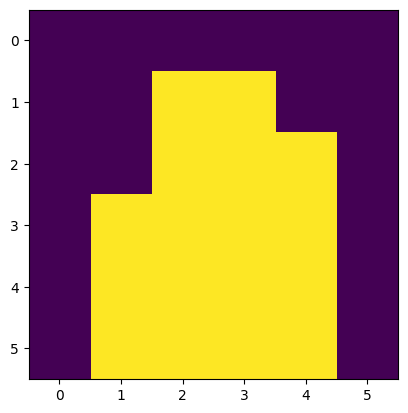

In [72]:
plt.imshow(aper, origin="upper")

### Summing flux in aperture for each cadence

In [43]:
row, col = np.where(aper)

In [54]:
flux[:].to_dataframe(row, col)

""


In [56]:
row_indices = np.atleast_1d(row)
col_indices = np.atleast_1d(col)
series_index = np.asarray(row_indices) * flux.ncol + np.asarray(col_indices)

In [59]:
flux.iloc[:, series_index]

,,series,8,9,14,15,16,19,20,21,22,25,26,27,28,31,32,33,34
,,pixel_row,258,258,259,259,259,260,260,260,260,261,261,261,261,262,262,262,262
,,pixel_column,1630,1631,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632
time_index,btjd,spacecraft_time,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,42657.632812,65179.886719,100720.773438,101675.906250,42470.730469,29425.457031,102240.070312,103746.945312,61337.554688,26175.996094,103074.070312,105171.984375,40686.078125,11072.824219,102138.585938,104423.625000,10715.317383
1,1325.345094,1325.344340,42648.261719,65202.703125,100720.617188,101675.750000,42489.433594,29410.039062,102239.914062,103746.789062,61370.964844,26143.367188,103073.914062,105171.820312,40717.785156,11068.058594,102138.429688,104423.468750,10720.024414
2,1325.365927,1325.365173,42482.433594,65449.781250,100720.492188,101689.953125,42563.906250,29321.394531,102246.984375,103753.929688,61504.335938,26041.806641,103073.796875,105179.046875,40789.992188,11046.513672,102138.304688,104430.640625,10729.130859
3,1325.386761,1325.386006,42606.925781,65420.988281,100713.601562,101675.585938,42549.976562,29406.074219,102240.031250,103746.632812,61454.304688,26063.630859,103066.804688,105164.296875,40812.726562,11046.653320,102131.343750,104423.312500,10736.232422
4,1325.407594,1325.406840,42386.238281,65640.031250,100706.531250,101682.976562,42573.464844,29310.171875,102232.921875,103739.585938,61588.140625,25998.742188,103059.632812,105164.523438,40953.453125,11042.083008,102124.218750,104416.218750,10752.752930
5,1325.428427,1325.427673,42606.902344,65784.171875,100713.570312,101682.953125,42648.289062,29356.253906,102232.820312,103746.835938,61604.894531,25948.199219,103059.531250,105164.500000,40889.960938,11023.171875,102124.132812,104416.195312,10745.757812
6,1325.449260,1325.448506,42708.250000,65836.125000,100720.695312,101690.148438,42652.933594,29379.376953,102239.992188,103746.859375,61593.714844,25933.828125,103066.757812,105171.882812,40880.855469,11016.144531,102131.304688,104423.539062,10738.701172


In [60]:
flux.columns[series_index]

MultiIndex([( 8, 258, 1630),
            ( 9, 258, 1631),
            (14, 259, 1630),
            (15, 259, 1631),
            (16, 259, 1632),
            (19, 260, 1629),
            (20, 260, 1630),
            (21, 260, 1631),
            (22, 260, 1632),
            (25, 261, 1629),
            (26, 261, 1630),
            (27, 261, 1631),
            (28, 261, 1632),
            (31, 262, 1629),
            (32, 262, 1630),
            (33, 262, 1631),
            (34, 262, 1632)],
           names=['series', 'pixel_row', 'pixel_column'])

In [61]:
pd.DataFrame(
    flux.iloc[:, series_index],
    index=flux.index,
    columns=flux.columns[series_index],
)

,,series,8,9,14,15,16,19,20,21,22,25,26,27,28,31,32,33,34
,,pixel_row,258,258,259,259,259,260,260,260,260,261,261,261,261,262,262,262,262
,,pixel_column,1630,1631,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632
time_index,btjd,spacecraft_time,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,42657.632812,65179.886719,100720.773438,101675.906250,42470.730469,29425.457031,102240.070312,103746.945312,61337.554688,26175.996094,103074.070312,105171.984375,40686.078125,11072.824219,102138.585938,104423.625000,10715.317383
1,1325.345094,1325.344340,42648.261719,65202.703125,100720.617188,101675.750000,42489.433594,29410.039062,102239.914062,103746.789062,61370.964844,26143.367188,103073.914062,105171.820312,40717.785156,11068.058594,102138.429688,104423.468750,10720.024414
2,1325.365927,1325.365173,42482.433594,65449.781250,100720.492188,101689.953125,42563.906250,29321.394531,102246.984375,103753.929688,61504.335938,26041.806641,103073.796875,105179.046875,40789.992188,11046.513672,102138.304688,104430.640625,10729.130859
3,1325.386761,1325.386006,42606.925781,65420.988281,100713.601562,101675.585938,42549.976562,29406.074219,102240.031250,103746.632812,61454.304688,26063.630859,103066.804688,105164.296875,40812.726562,11046.653320,102131.343750,104423.312500,10736.232422
4,1325.407594,1325.406840,42386.238281,65640.031250,100706.531250,101682.976562,42573.464844,29310.171875,102232.921875,103739.585938,61588.140625,25998.742188,103059.632812,105164.523438,40953.453125,11042.083008,102124.218750,104416.218750,10752.752930
5,1325.428427,1325.427673,42606.902344,65784.171875,100713.570312,101682.953125,42648.289062,29356.253906,102232.820312,103746.835938,61604.894531,25948.199219,103059.531250,105164.500000,40889.960938,11023.171875,102124.132812,104416.195312,10745.757812
6,1325.449260,1325.448506,42708.250000,65836.125000,100720.695312,101690.148438,42652.933594,29379.376953,102239.992188,103746.859375,61593.714844,25933.828125,103066.757812,105171.882812,40880.855469,11016.144531,102131.304688,104423.539062,10738.701172


In [62]:
flux._frame_class(
    flux.iloc[:, series_index],
    index=flux.index,
    columns=flux.columns[series_index],
)

[autoreload of lightkurve.dataframe failed: Traceback (most recent call last):
  File "/opt/anaconda3/envs/lkdev/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/anaconda3/envs/lkdev/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/opt/anaconda3/envs/lkdev/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/opt/anaconda3/envs/lkdev/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/lkdev/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/opt/anaconda3/envs/lkdev/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 309, 

""


In [21]:
flux[:, aper].sum(axis=1)

📉 DataSeries (50,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        1.152913e+06
1        1325.345094  1325.344340        1.152961e+06
2        1325.365927  1325.365173        1.153162e+06
3        1325.386761  1325.386006        1.153259e+06
4        1325.407594  1325.406840        1.153372e+06
5        1325.428427  1325.427673        1.153748e+06
6        1325.449260  1325.448506        1.153931e+06
7        1325.470093  1325.469340        1.153963e+06
8        1325.490926  1325.490173        1.154115e+06
9        1325.511759  1325.511006        1.154479e+06
10       1325.532593  1325.531840        1.154678e+06
11       1325.553426  1325.552673        1.154814e+06
12       1325.574259  1325.573506        1.155328e+06
13       1325.595092  1325.594340        1.155592e+06
14       1325.615925  1325.615173        1.155505e+06
15       1325.636758  1325.636006        1.155915e+06
16       1325.657591  1325.656839        1.156165e+06
17       1325.678425  132

### Background median flux, by cadence

In [22]:
flux[:, ~aper].median(axis=1)

📉 DataSeries (50,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        3497.708008
1        1325.345094  1325.344340        3498.899414
2        1325.365927  1325.365173        3501.454590
3        1325.386761  1325.386006        3501.558594
4        1325.407594  1325.406840        3509.732422
5        1325.428427  1325.427673        3508.302002
6        1325.449260  1325.448506        3512.454102
7        1325.470093  1325.469340        3515.292480
8        1325.490926  1325.490173        3521.904541
9        1325.511759  1325.511006        3524.561523
10       1325.532593  1325.531840        3523.095215
11       1325.553426  1325.552673        3532.658936
12       1325.574259  1325.573506        3533.626465
13       1325.595092  1325.594340        3535.393066
14       1325.615925  1325.615173        3539.587158
15       1325.636758  1325.636006        3544.908203
16       1325.657591  1325.656839        3540.203369
17       1325.678425  1325.677673        3

## Sum of flux error in aperture, per cadence. 

In [28]:
flux_err[:, aper].sum(axis=1)

📈 ErrorSeries (50,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        29.298033
1        1325.345094  1325.344340        29.298598
2        1325.365927  1325.365173        29.301073
3        1325.386761  1325.386006        29.302346
4        1325.407594  1325.406840        29.303881
5        1325.428427  1325.427673        29.308586
6        1325.449260  1325.448506        29.310932
7        1325.470093  1325.469340        29.311349
8        1325.490926  1325.490173        29.313353
9        1325.511759  1325.511006        29.317865
10       1325.532593  1325.531840        29.320498
11       1325.553426  1325.552673        29.322088
12       1325.574259  1325.573506        29.328599
13       1325.595092  1325.594340        29.332034
14       1325.615925  1325.615173        29.330935
15       1325.636758  1325.636006        29.336104
16       1325.657591  1325.656839        29.339302
17       1325.678425  1325.677673        29.336464
18       1325.699258  13

# Folding
TODO: Time difference between lk v2 and this

In [58]:
flux

📘 DataCube (50, 6, 6)

In [61]:
flux.meta

📘 DataCube (50, 6, 6) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

In [64]:
flux.btjd.min()

1325.324261183436

In [63]:
flux.btjd.max()

1326.3450855298036

In [59]:
# df

📘 DataCube (200, 10, 14)

In [73]:
np.arange(6)[:, None] * np.ones((6, 6))

array([[0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1.],
       [2., 2., 2., 2., 2., 2.],
       [3., 3., 3., 3., 3., 3.],
       [4., 4., 4., 4., 4., 4.],
       [5., 5., 5., 5., 5., 5.]])

In [79]:
len(flux.pixel_row)

36

In [30]:
flux.fold(0.3, inplace=True, label="btjd_phase")

In [31]:
flux

📘 DataCube (50, 6, 6)

In [77]:
folded = flux.fold(0.3)
folded

📘 DataCube (50, 6, 6)

### Looking at single row converts to DataFrame, this is expected

In [78]:
folded[:10, 0, :]

,,,series,0,1,2,3,4,5
,,,pixrow,257,257,257,257,257,257
,,,pixcol,1628,1629,1630,1631,1632,1633
cadence,btjd,spacecraft_time,phase,,,,,,
0,1325.324261,1325.323506,0.000000,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
1,1325.345094,1325.344340,0.069444,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365
2,1325.365927,1325.365173,0.138888,975.665710,967.891174,942.014038,1165.668457,1619.722168,2290.568604
3,1325.386761,1325.386006,0.208331,979.376587,972.970520,945.712402,1159.484375,1623.469971,2293.927002
4,1325.407594,1325.406840,0.277775,979.624390,973.837219,947.865112,1161.242310,1623.600952,2294.077637
5,1325.428427,1325.427673,0.347219,983.042419,978.066895,949.849365,1165.843384,1626.385376,2299.407715
6,1325.449260,1325.448506,0.416663,985.820435,980.250061,951.908569,1169.730103,1630.028198,2302.799072


### Looking at a single cadence does not convert to a DataFrame, is a single element DataCube

In [80]:
folded[0, :3, :3]

📘 DataCube (1, 3, 3)

## Convenient that sort_values works... but unexpected dc$\rightarrow$df "conversion"

In [32]:
folded.sort_values(by="phase")

,,,series,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
,,,pixel_row,257,257,257,257,257,257,258,258,258,258,...,261,261,261,261,262,262,262,262,262,262
,,,pixel_column,1628,1629,1630,1631,1632,1633,1628,1629,1630,1631,...,1630,1631,1632,1633,1628,1629,1630,1631,1632,1633
cadence,btjd,spacecraft_time,phase,,,,,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,0.000000,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133,2091.041260,2403.761475,42657.632812,65179.886719,...,103074.070312,105171.984375,40686.078125,4181.030273,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008
29,1325.928422,1325.927673,0.013870,1022.008789,1017.371277,992.677368,1205.549805,1675.377930,2356.410889,2141.015869,2467.567871,43096.500000,68442.468750,...,103008.914062,105127.710938,41458.894531,4242.437012,3491.969971,10842.014648,102059.390625,104379.648438,10813.754883,3554.153809
15,1325.636758,1325.636006,0.041657,1008.499329,1003.342041,976.711731,1192.492676,1657.128418,2336.848145,2127.663574,2451.052246,42745.492188,67310.953125,...,103016.429688,105127.960938,41331.421875,4232.372070,3496.219482,10924.523438,102074.062500,104379.898438,10809.369141,3544.908203
44,1326.240920,1326.240173,0.055528,1024.433105,1017.674561,994.234192,1208.838623,1676.309937,2356.109131,2144.079590,2471.985596,42520.347656,68992.257812,...,102980.820312,105099.210938,41913.203125,4259.364258,3484.945557,10800.898438,102024.273438,104351.343750,10885.234375,3565.734375
1,1325.345094,1325.344340,0.069444,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365,2088.742188,2404.846924,42648.261719,65202.703125,...,103073.914062,105171.820312,40717.785156,4182.341797,3494.455322,11068.058594,102138.429688,104423.468750,10720.024414,3498.899414
30,1325.949255,1325.948506,0.083314,1020.777466,1014.113464,990.250000,1204.264282,1674.736206,2352.281738,2141.237793,2466.788330,42874.878906,68531.125000,...,103009.328125,105127.992188,41637.496094,4251.505371,3485.535645,10828.302734,102059.812500,104379.929688,10839.880859,3557.117432
16,1325.657591,1325.656839,0.111101,1009.213867,1004.830933,978.269958,1195.137451,1660.215332,2337.270508,2131.110107,2452.632812,42962.007812,67363.039062,...,103023.093750,105134.835938,41221.449219,4228.779297,3496.828369,10921.512695,102073.500000,104386.734375,10780.608398,3540.203369


# Plot the light curve

<ErrorbarContainer object of 3 artists>

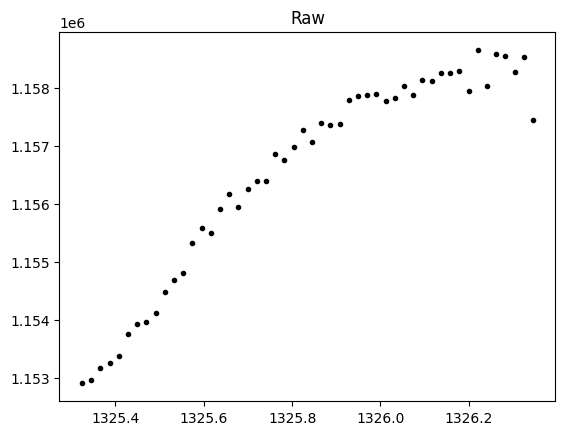

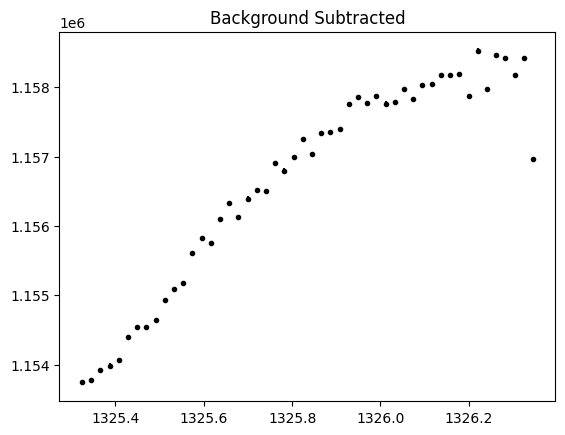

In [34]:
import matplotlib.pyplot as plt

time = np.asarray(flux.btjd)
bkg = flux[:, bkg_aper].mean(axis=1)
bkg_err = flux_err[:, bkg_aper].mean(axis=1)

bkg -= bkg.median()

lc = flux[:, aper].sum(axis=1)
lc_err = flux_err[:, aper].sum(axis=1)

plt.figure()
plt.title("Raw")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(.88e6, .94e6)

lc = flux[:, aper].sum(axis=1) - (bkg * aper.sum())
lc_err = flux_err[:, aper].sum(axis=1) + (bkg_err * aper.sum())

plt.figure()
plt.title("Background Subtracted")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(0.88e6, 0.94e6)

# Tests

## Check types when transformed

In [29]:
type(flux), type(flux_err)

(lightkurve.datacube.DataCube, lightkurve.datacube.ErrorCube)

In [30]:
type(flux[:, aper]), type(flux_err[:, aper])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [31]:
type(flux[:, 0, :]), type(flux_err[:, 0, :])
type(flux[:, :, 0]), type(flux_err[:, :, 0])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [32]:
type(flux[:, 0, 0]), type(flux_err[:, 0, 0])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [ ]:
all(flux.to_dataframe(slice(0, 3), slice(0, 2)) == flux[:, :3, :2])

True

In [33]:
type(flux[:, aper].sum(axis=0)), type(flux_err[:, aper].sum(axis=0))
type(flux[:, aper].sum(axis=1)), type(flux_err[:, aper].sum(axis=1))

(lightkurve.dataseries.DataSeries, lightkurve.dataseries.ErrorSeries)

## Smaller test data

In [ ]:
from lksearch import TESSSearch
from astropy.coordinates import SkyCoord

search_input = (84.291190, -80.469170)
search_input = SkyCoord(*search_input, unit="deg", frame="icrs")
search_result = TESSSearch(search_input, hlsp=False)

# You can filter two different ways to get the same result.
# search_result.filter_table(pipeline='TESScut')
downloads_table = search_result.tesscut.filter_table(sector=1).download(TESScut_size=6)
hdulist = fits.open(downloads_table["Local Path"][0])

In [ ]:
hdulist = fits.open(
    "/Users/dkgiles/.lksearch/cache/mastDownload/TESSCut/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

In [ ]:
hdulist[1].data = hdulist[1].data[:50]

In [ ]:
hdulist.writeto(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits",
)

In [ ]:
row = flux.pixel_row

In [ ]:
dr = np.median(np.diff(np.sort(np.unique(row)))) * 3
bins_row = np.arange(row.min(), row.max() + dr, dr)

In [ ]:
bins_row

In [ ]:
bin_edges_left_row = pd.cut(np.sort(row), bins_row, right=False)

In [ ]:
bin_edges_left_row

In [ ]:
flux.sum().sum()

In [ ]:
flux.spatial_downsample(2).sum().sum()

In [ ]:
flux[:, :-1].spatial_downsample(2)

In [ ]:
flux[:, :-2].sum().sum()

In [ ]:
flux[:, :-1].spatial_downsample(2).sum().sum()

In [ ]:
flux[:, :, :-1].spatial_downsample(2)

In [ ]:
flux[:, :, :-2].sum().sum()

In [ ]:
flux[:, :, :-1].spatial_downsample(2).sum().sum()

In [ ]:
flux.spatial_downsample(2).to_array()[0]

In [ ]:
def single_cadence_frame(datacube, cadence):
    indices = [f"{i[0]} {i[1]}" for i in zip(datacube.index.names, datacube.index[0])]
    str_index = "; ".join(indices)
    return pd.DataFrame(
        datacube.to_array()[cadence],
        index=pd.Series(datacube.row[:: datacube.nrow], name="row"),
        columns=pd.Series(datacube.column[: datacube.ncol], name="column"),
    ).style.set_caption(str_index)

In [ ]:
f0 = single_cadence_frame(flux, 0)
f0

In [ ]:
f0.style.set_caption("name")

In [ ]:
f0.index.name = "row"

In [ ]:
f0.columns.name = "column"

In [ ]:
f0

In [ ]:
[f"{i[0]}, {i[1]}" for i in zip(flux.index.names, flux.index[0])]

In [ ]:
flux.to_dataframe(0, 0)

In [ ]:
flux.index[0]

In [ ]:
c = 0

In [ ]:
with np.printoptions(edgeitems=2, threshold=5):
    print(flux)
    for c in [0, -1]:
        indices = [
            (flux.index.names[i], flux.index[c][i])
            for i in range(len(flux.index.names))
        ]
        print(f"""{indices}\n{flux.to_array()[c]}\n...""")

In [ ]:
with pd.option_context("display.max_columns", 4):
    print(flux)
    for c in [0, -1]:
        indices = [
            (flux.index.names[i], flux.index[c][i])
            for i in range(len(flux.index.names))
        ]
        print(f"""{indices}\n{single_cadence_frame(flux, c)}\n...""")

In [ ]:
pd.set_option("display.max.columns", 4)

In [ ]:
print(repr(single_cadence_frame(flux, 0)))

In [ ]:
print(flux._repr_html_())

## Dummy data

In [3]:
ntime, nrow, ncol = 200, 10, 14
test_data = np.ones((ntime, nrow, ncol))
row, col = np.arange(test_data.shape[1]), np.arange(test_data.shape[2])
df = DataCube(test_data, row_indices={"row": row}, col_indices={"column": col})
df_err = ErrorCube(test_data, row_indices={"row": row}, col_indices={"column": col})

In [4]:
df, df_err

(📘 DataCube (200, 10, 14), 📕 ErrorCube (200, 10, 14))

In [14]:
all(df.spatial_downsample((2, 1)) == 2)

True

In [9]:
df.info()

<class 'lightkurve.datacube.DataCube'>
MultiIndex: 200 entries, (0,) to (199,)
Columns: 140 entries, (0, 0, 0) to (139, 9, 13)
dtypes: float64(140)
memory usage: 228.9 KB


In [10]:
# df

📘 DataCube (200, 10, 14)

In [12]:
DataCube?

Init signature:
DataCube(
    data,
    ntime=None,
    nrow=None,
    ncol=None,
    time_indices={},
    row_indices={'row': array([0, 1, 2, 3, 4, 5])},
    col_indices={'column': array([0, 1, 2, 3, 4, 5])},
    index=None,
    columns=None,
)
Docstring:      Defines a mixin class which will let us postprocess all our pandas stats
File:           ~/Repositories/secret/src/lightkurve/datacube.py
Type:           type
Subclasses:     ErrorCube

In [11]:
df.fold(3)

ValueError: operands could not be broadcast together with shapes (6,1) (10,14) 

In [67]:
df_err

column,0,1,2,3,4,5,6,7,8,9,...
row,,,,,,,,,,,
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...


In [377]:
new_index = df.index.to_frame()
new_index["time"] = new_index["cadence"] / 100
new_index = new_index.set_index("time", append=True)

In [381]:
df.index = new_index.index

In [156]:
df.index.get_level_values(-1)[2]

0.02

In [429]:
df.downsample(2, level=-1)

column,0,1,2,3,4,5,6,7,8,9,...
row,,,,,,,,,,,
0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
1,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
2,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
3,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
4,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
5,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
6,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
7,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
8,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...


In [320]:
nframes = 2
index = df.index.get_level_values(-1)
# Find the average spacing of the index
dt = np.median(np.diff(index)) * nframes
nbins = int(np.ceil((index.max() - index.min()) / dt) + 1)
# Calculate what bin edges result in this spacing
bins = np.arange(index.min(), index.min() + nbins * dt, dt)
bin_edges_left = pd.cut(
    np.sort(index), bins.round(16), right=False, include_lowest=True
)
# bin_edges_right = pd.cut(np.sort(index), bins, right=True)
# groupby these bin edges

gb = df.groupby(bin_edges_left, observed=False)

new = gb.sum()
# We only accept cases where the number of points in a bin is the same as the number of frames we downsample to
count = gb[int(df.columns.get_level_values(0)[0])].count()

In [255]:
arr = np.arange(0.0, 2.0, 0.01)
bins = np.linspace(0.0, 2.0, 101)
pd.cut(arr[:5], bins, right=False, include_lowest=True)

[[0.0, 0.02), [0.0, 0.02), [0.02, 0.04), [0.02, 0.04), [0.04, 0.06)]
Categories (100, interval[float64, left]): [[0.0, 0.02) < [0.02, 0.04) < [0.04, 0.06) < [0.06, 0.08) ... [1.92, 1.94) < [1.94, 1.96) < [1.96, 1.98) < [1.98, 2.0)]

In [ ]:
(df.downsample(2).to_array() == 2).all()

In [ ]:
(df.spatial_downsample(3) == 9).all().all()

In [76]:
df.spatial_downsample((1, 2))

column,0,2,4,6,8,10,12
row,,,,,,,
0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
1,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
2,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
3,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
4,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
5,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
6,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
7,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
8,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [73]:
df.spatial_downsample((5, 7))

column,0,7
row,,
0,35.000000,35.000000
5,35.000000,35.000000


In [74]:
df.spatial_downsample(3)

column,0,3,6,9
row,,,,
0,9.000000,9.000000,9.000000,9.000000
3,9.000000,9.000000,9.000000,9.000000
6,9.000000,9.000000,9.000000,9.000000


In [ ]:
df_err.spatial_downsample(3)

In [ ]:
(df.downsample(3).to_array() == 3).all()

In [ ]:
(df.spatial_aggregate(5, 7).to_array().round() == 4).all()

In [ ]:
(df.spatial_downsample(2).to_array() == 4).all()

In [ ]:
(
    df[:, :, :-1].spatial_downsample(2).to_array()
    == df[:, :, :-2].spatial_downsample(2).to_array()
).all()

In [ ]:
(df_err.downsample(4).to_array() == 2).all()

In [ ]:
(df_err.downsample(9).to_array() == 3).all()

In [ ]:
(df_err.to_array()[0][0] ** 2).sum()

In [ ]:
df_err

In [ ]:
df_err.spatial_aggregate(5, 7)

In [ ]:
assert (df_err.spatial_aggregate(5, 7).to_array().round() == 2).all()

In [ ]:
flux[:, [1, 2, 3], [1, 2, 3]]

In [350]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Phase (period = 0.3d)')

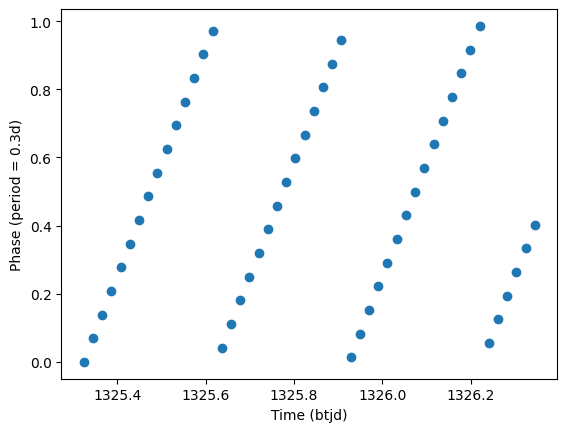

In [353]:
plt.scatter(folded.btjd, folded.phase)
plt.xlabel("Time (btjd)")
plt.ylabel("Phase (period = 0.3d)")

In [374]:
flux.fold(0.3, inplace=True)
flux

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
258,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
259,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
260,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
261,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
262,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [355]:
flux.phase

Index([                 0.0,   0.0694437541771246,  0.13888751319958223,
         0.2083312768771369,   0.2777750452135782,  0.34721881801412263,
        0.41666259508550263,   0.4861063766164383,   0.5555501622203944,
         0.6249939517033454,   0.6944377452653802,    0.763881542704894,
         0.8333253438331667,   0.9027691486479247,   0.9722129569536264,
        0.04165676855852026,  0.11110058346184819,   0.1805444018599095,
         0.2499882231653222,  0.31943204757514354,  0.38887587489458997,
         0.4583197051266932,   0.5277635380736381,   0.5972073737369404,
         0.6666512121203899,   0.7360950528283563,   0.8055388962534381,
         0.8749827418112849,   0.9444265898899479, 0.013870440108955107,
        0.08331429246072738,   0.1527581469437489,  0.22220200336854162,
         0.2916458619253415,  0.36108972223140284,  0.43053358447847745,
        0.49997744866504956,   0.5694213144023101,   0.6388651818835267,
         0.7083090509199793,   0.7777529217034196, 

# TODO: Make `.loc` useful
I want to make the `.loc` act similar to how astropy uses it so that users can slice on the "row" and "column" values instead of the their indices

In [410]:
# this should return a DataCube
idx = pd.IndexSlice[:, 257:259]
flux.loc[:, idx]

,,series,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
,,pixel_row,257,257,257,257,257,257,258,258,258,258,258,258,259,259,259,259,259,259
,,pixel_column,1628,1629,1630,1631,1632,1633,1628,1629,1630,1631,1632,1633,1628,1629,1630,1631,1632,1633
cadence,btjd,spacecraft_time,,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
1,1325.345094,1325.344340,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365,2088.742188,2404.846924,42648.261719,65202.703125,8307.278320,7378.449707,4117.688477,6245.666992,100720.617188,101675.750000,42489.433594,8948.191406
2,1325.365927,1325.365173,975.665710,967.891174,942.014038,1165.668457,1619.722168,2290.568604,2094.772949,2410.153076,42482.433594,65449.781250,8313.223633,7391.889160,4120.398926,6247.192871,100720.492188,101689.953125,42563.906250,8960.819336
3,1325.386761,1325.386006,979.376587,972.970520,945.712402,1159.484375,1623.469971,2293.927002,2095.965820,2413.635254,42606.925781,65420.988281,8325.699219,7388.116699,4126.354980,6254.471680,100713.601562,101675.585938,42549.976562,8965.175781
4,1325.407594,1325.406840,979.624390,973.837219,947.865112,1161.242310,1623.600952,2294.077637,2098.286865,2413.797607,42386.238281,65640.031250,8319.634766,7396.021973,4122.250977,6249.279785,100706.531250,101682.976562,42573.464844,8982.336914
5,1325.428427,1325.427673,983.042419,978.066895,949.849365,1165.843384,1626.385376,2299.407715,2102.291260,2419.361328,42606.902344,65784.171875,8344.448242,7407.568848,4130.815918,6263.557129,100713.570312,101682.953125,42648.289062,8980.118164
6,1325.449260,1325.448506,985.820435,980.250061,951.908569,1169.730103,1630.028198,2302.799072,2102.219727,2421.653809,42708.250000,65836.125000,8365.102539,7411.581055,4130.745117,6272.555176,100720.695312,101690.148438,42652.933594,8984.502930


# TODO: Pixel coordinates $\rightarrow$ WCS

In [29]:
c0

1628

In [74]:
transform = np.array(
    [hdulist[1].header[key] for key in ["11PC4", "12PC4", "21PC4", "22PC4"]]
)
transform = transform.reshape((2, 2))
transform

array([[ 0.00355271,  0.00434128],
       [-0.00414498,  0.00324576]])

In [75]:
ref_coord = np.array([hdulist[1].header[key] for key in ["1CRVL4", "2CRVL4"]])
ref_coord

array([ 84.26834729, -80.46750255])

In [138]:
np.matmul(ref_coord, transform)

array([0.63291758, 0.10465414])

In [123]:
pix_coord = np.array([c0, r0])

In [125]:
np.matmul(transform, pix_coord)

array([ 6.89952536, -5.91386987])

In [110]:
np.matmul(np.array([1628 + 3.49895, 257 + 3.49321]), transform.T)

array([ 6.92712112, -5.91703483])

In [109]:
ref_coord / np.matmul(np.array([1628 + 3.49895, 257 + 3.49321]), transform.T)

array([12.1649883 , 13.59929506])

In [80]:
from astropy.wcs import WCS

In [102]:
w = WCS(hdulist[1].header)

Set MJD-END to 58352.666904 from DATE-END'. [astropy.wcs.wcs]


In [126]:
w

WCS Keywords

Number of WCS axes: 2
CTYPE : ''  ''  
CRVAL : 0.0  0.0  
CRPIX : 0.0  0.0  
PC1_1 PC1_2  : 1.0  0.0  
PC2_1 PC2_2  : 0.0  1.0  
CDELT : 1.0  1.0  
NAXIS : 786  50

In [139]:
wcs_dict = {
    "CTYPE1": "RA---TAN",
    "CTYPE2": "DEC--TAN",
    "CDELT1": 1.0,
    "CDELT2": 1.0,
    "CRPIX1": 3.4989488609339,
    "CRPIX2": 3.49320911051,
    "CRVAL1": 84.268347291172,
    "CRVAL2": -80.467502554136,
    "PC1_1": 0.0035527132290707,
    "PC1_2": 0.0043412771212979,
    "PC2_1": -0.0041449815015788,
    "PC2_2": 0.0032457588306464,
    "NAXIS1": 786,
    "NAXIS2": 50,
}

In [140]:
input_wcs = WCS(wcs_dict)
input_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 84.268347291172  -80.467502554136  
CRPIX : 3.4989488609339  3.49320911051  
PC1_1 PC1_2  : 0.0035527132290707  0.0043412771212979  
PC2_1 PC2_2  : -0.0041449815015788  0.0032457588306464  
CDELT : 1.0  1.0  
NAXIS : 786  50

In [141]:
sky = input_wcs.pixel_to_world(3.4989488609339, 3.49320911051)

print(sky)

<SkyCoord (ICRS): (ra, dec) in deg
    (84.31601875, -80.46839854)>


In [118]:
input_wcs.world_to_pixel(sky)

(array(3.49894886), array(3.49320911))

In [36]:
hdulist[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  786 / length of dimension 1                          
NAXIS2  =                   50 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   12 / number of table fields                         
WCAX4   =                    2 / number of WCS axes                             
1CTYP4  = 'RA---TAN'           / right ascension coordinate type                
2CTYP4  = 'DEC--TAN'           / declination coordinate type                    
1CRPX4  =      3.4989488609339 / [pixel] reference pixel along image axis 1     
2CRPX4  =        3.493209110

In [290]:
ds.index.names

FrozenList(['cadence', 'btjd', 'spacecraft_time', 'cadences'])